MAE: 970043.403920162
MSE: 1754318687330.684
R²: 0.6529242642153144


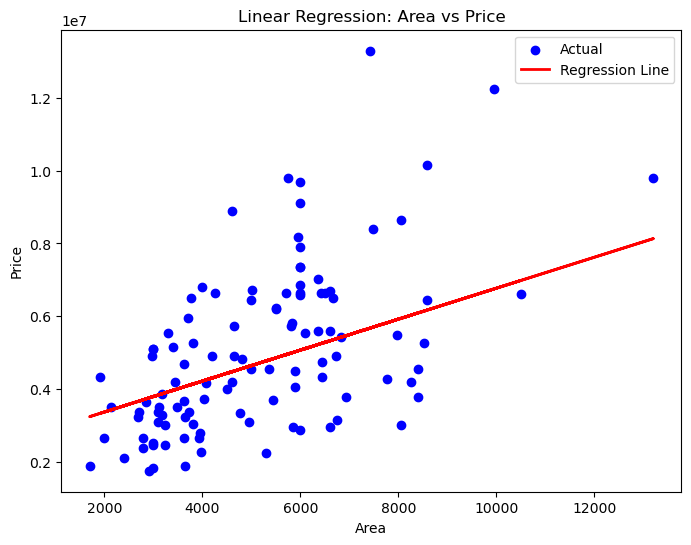

Coefficient (slope): 425.72984193878284
Intercept: 2512254.2639593435


In [13]:
# Assistant
# Load the dataset from the specific path you provided
import pandas as pd
import os

# Use the exact path you provided
file_path = r"C:\Users\bond9\Downloads\archive (2)\Housing.csv"

# Load the dataset
df = pd.read_csv(file_path)

# ## Step 2: Split Data into Train-Test Sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop("price", axis=1)
y = df["price"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ## Step 3: Fit a Linear Regression Model
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

# ## Step 4: Evaluate Model using MAE, MSE, R²
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

# ## Step 5: Plot Regression Line (Area vs Price) and Interpret Coefficients
import matplotlib.pyplot as plt

# Train simple regression on 'area'
X_area = df[['area']]
y_price = df['price']

X_train_area, X_test_area, y_train_area, y_test_area = train_test_split(
    X_area, y_price, test_size=0.2, random_state=42
)

lin_reg_area = LinearRegression()
lin_reg_area.fit(X_train_area, y_train_area)

y_pred_area = lin_reg_area.predict(X_test_area)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_test_area, y_test_area, color="blue", label="Actual")
plt.plot(X_test_area, y_pred_area, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression: Area vs Price")
plt.legend()
plt.show()

print("Coefficient (slope):", lin_reg_area.coef_[0])
print("Intercept:", lin_reg_area.intercept_)